In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.data_preparation import load_and_prepare_data
from src.pipeline.feature_pipeline import FeaturePipeline

paths = load_paths()
logger = setup_logger(level="INFO")

SEED = 42

COMPACT_FEATURES = [
    "sz_coef_variation",
    "sz_p25_median_ratio",
    "sz_p75_median_ratio",
    "sz_mean_max",
    "sz_mean_min",
    "sz_std_max",
    "sz_std_min",
    "session_mean_prob",
    "session_var_prob",
    "session_top_k_mean_prob",
    "session_consecutive_high_runs",
    "session_fraction_high"
]

# NOTE: IAT features moved to experimental (dataset leakage detected - AUC = 0.93)
IAT_EXPERIMENTAL_FEATURES = [
    "iat_all_mean",
    "iat_all_std",
    "iat_all_p25",
    "iat_all_median",
    "iat_all_p75",
    "iat_mean_max",
    "iat_mean_min",
    "iat_std_max",
    "iat_std_min"
]

print(f"Using Compact feature set: 12 features (excluding IAT and duplicates)")
print(f"IAT features available for experimental use: 9 features")


In [2]:
df_all = load_and_prepare_data()

df_train = df_all[df_all["split"] == "train"].copy()
df_val = df_all[df_all["split"] == "val"].copy()
df_test = df_all[df_all["split"] == "test"].copy()

pipe = FeaturePipeline().fit(df_train)
all_model_features = pipe.model_feature_names()

for forbidden in ["source_capture_id", "source_file", "capture_id", "flow_id", "dataset", "split", "app", "connection_str"]:
    if forbidden in all_model_features:
        raise ValueError(f"Forbidden metadata leaked into model features: {forbidden}")

missing_compact = [f for f in COMPACT_FEATURES if f not in all_model_features]
if missing_compact:
    raise ValueError(f"Compact features missing from pipeline: {missing_compact}")

print("Datasets by split:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))
print("\nUsing robust features:")
print(COMPACT_FEATURES)

2026-03-28 12:48:37 | INFO | ai-vpn-firewall | Loading VNAT (PCAP-based)...
2026-03-28 12:49:07 | INFO | ai-vpn-firewall | Loading ISCX (PCAP-based)...
2026-03-28 12:50:01 | INFO | ai-vpn-firewall | Loading USBVPN (JSON-based)...
2026-03-28 12:50:02 | INFO | ai-vpn-firewall | Ensuring numeric dtypes for feature columns...
2026-03-28 12:50:02 | INFO | ai-vpn-firewall | âœ“ All feature columns successfully converted to numeric dtypes
2026-03-28 12:50:02 | INFO | ai-vpn-firewall | Metadata columns present for analysis only: ['source_capture_id', 'source_file']
2026-03-28 12:50:02 | INFO | ai-vpn-firewall | Multi-Domain Pool Created: (69558, 37)
2026-03-28 12:50:02 | INFO | ai-vpn-firewall | Datasets: {'usbvpn': 49650, 'iscx': 11801, 'vnat': 8107}
2026-03-28 12:50:02 | INFO | ai-vpn-firewall | Splits: {'train': 51499, 'test': 9384, 'val': 8675}
Datasets by split:
dataset  iscx  usbvpn  vnat
split                      
test     1634    7540   210
train    8388   35361  7750
val      1779   

In [3]:
def metric_row(y_true, p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0

    return {
        "roc_auc": roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan,
        "recall": recall,
        "precision": precision,
        "fpr": fpr,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n_test": int(len(y_true)),
        "n_neg": int((y_true == 0).sum()),
        "n_pos": int((y_true == 1).sum()),
    }


def fit_xgb(df_fit, feature_cols):
    X = pipe.transform(df_fit)[feature_cols]
    y = df_fit["label"].astype(int).values

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=SEED,
        n_jobs=4
    )
    model.fit(X, y)
    return model


def predict_df(model, df_eval, feature_cols):
    X = pipe.transform(df_eval)[feature_cols]
    p = model.predict_proba(X)[:, 1]
    y = df_eval["label"].astype(int).values
    return y, p


def find_val_threshold_for_fpr(y_val, p_val, target_fpr=0.01):
    order = np.argsort(p_val)[::-1]
    y_sorted = y_val[order]
    p_sorted = p_val[order]

    cum_fp = np.cumsum(y_sorted == 0)
    total_neg = int((y_sorted == 0).sum())

    if total_neg == 0:
        return 0.99

    fprs = cum_fp / total_neg
    valid_idx = np.where(fprs <= target_fpr)[0]
    if len(valid_idx) == 0:
        return 0.99
    return float(p_sorted[valid_idx[-1]])

In [4]:
print("="*80)
print("LEAVE-ONE-DATASET-OUT EVALUATION")
print("="*80)

dataset_names = ["vnat", "iscx", "usbvpn"]
rows = []

for held_out in dataset_names:
    train_df = df_train[df_train["dataset"] != held_out].copy()
    test_df = df_test[df_test["dataset"] == held_out].copy()
    val_df_local = df_val[df_val["dataset"] != held_out].copy()

    if train_df.empty or test_df.empty:
        continue

    model = fit_xgb(train_df, COMPACT_FEATURES)
    y_val_local, p_val_local = predict_df(model, val_df_local, COMPACT_FEATURES)
    thr = find_val_threshold_for_fpr(y_val_local, p_val_local, target_fpr=0.01)

    y_test_local, p_test_local = predict_df(model, test_df, COMPACT_FEATURES)
    row = metric_row(y_test_local, p_test_local, threshold=thr)
    row["train_on"] = "+".join(sorted(train_df["dataset"].unique()))
    row["test_on"] = held_out
    row["threshold"] = thr
    rows.append(row)

lood_df = pd.DataFrame(rows)
print(lood_df.to_string(index=False, float_format="%.4f"))

LEAVE-ONE-DATASET-OUT EVALUATION
 roc_auc  pr_auc  recall  precision    fpr   tn  fp   fn  tp  n_test  n_neg  n_pos    train_on test_on  threshold
  0.1878  0.0751  0.0000     0.0000 0.1929  159  38   13   0     210    197     13 iscx+usbvpn    vnat     0.5017
  0.3322  0.1162  0.0042     0.1111 0.0057 1388   8  237   1    1634   1396    238 usbvpn+vnat    iscx     0.2059
  0.5998  0.1651  0.0116     0.1250 0.0129 6418  84 1026  12    7540   6502   1038   iscx+vnat  usbvpn     0.7190


In [5]:
print("="*80)
print("DOMAIN-BALANCED TRAINING EXPERIMENT")
print("="*80)

def make_domain_balanced_train(df_train_in, seed=42):
    rng = np.random.default_rng(seed)
    out_parts = []

    datasets = sorted(df_train_in["dataset"].unique())
    per_dataset_counts = df_train_in["dataset"].value_counts()
    target_n = int(per_dataset_counts.min())

    for ds in datasets:
        sub = df_train_in[df_train_in["dataset"] == ds].copy()

        class_counts = sub["label"].value_counts()
        n_pos = int(class_counts.get(1, 0))
        n_neg = int(class_counts.get(0, 0))

        target_per_class = min(n_pos, n_neg, target_n // 2) if min(n_pos, n_neg) > 0 else min(target_n, len(sub))

        if target_per_class > 0 and n_pos > 0 and n_neg > 0:
            pos = sub[sub["label"] == 1].sample(n=target_per_class, random_state=seed, replace=False)
            neg = sub[sub["label"] == 0].sample(n=target_per_class, random_state=seed, replace=False)
            sub_bal = pd.concat([pos, neg], ignore_index=True)
        else:
            sub_bal = sub.sample(n=min(target_n, len(sub)), random_state=seed, replace=False)

        out_parts.append(sub_bal)

    out = pd.concat(out_parts, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

baseline_train = df_train.copy()
balanced_train = make_domain_balanced_train(df_train, seed=SEED)

print("Baseline train counts:")
print(pd.crosstab(baseline_train["dataset"], baseline_train["label"]))

print("\nBalanced train counts:")
print(pd.crosstab(balanced_train["dataset"], balanced_train["label"]))

rows = []
for train_name, train_df_variant in [("baseline_pooled", baseline_train), ("dataset_balanced", balanced_train)]:
    model = fit_xgb(train_df_variant, COMPACT_FEATURES)
    y_val, p_val = predict_df(model, df_val, COMPACT_FEATURES)
    thr = find_val_threshold_for_fpr(y_val, p_val, target_fpr=0.01)

    y_test, p_test = predict_df(model, df_test, COMPACT_FEATURES)
    row = metric_row(y_test, p_test, threshold=thr)
    row["train_variant"] = train_name
    row["threshold"] = thr
    rows.append(row)

    for ds in sorted(df_test["dataset"].unique()):
        sub = df_test[df_test["dataset"] == ds].copy()
        y_ds, p_ds = predict_df(model, sub, COMPACT_FEATURES)
        r = metric_row(y_ds, p_ds, threshold=thr)
        r["train_variant"] = train_name
        r["dataset"] = ds
        r["threshold"] = thr
        rows.append(r)

domain_balanced_df = pd.DataFrame(rows)
print(domain_balanced_df.to_string(index=False, float_format="%.4f"))

DOMAIN-BALANCED TRAINING EXPERIMENT
Baseline train counts:
label        0     1
dataset             
iscx      6359  2029
usbvpn   29726  5635
vnat      7401   349

Balanced train counts:
label       0     1
dataset            
iscx     2029  2029
usbvpn   3875  3875
vnat      349   349
 roc_auc  pr_auc  recall  precision    fpr   tn  fp  fn  tp  n_test  n_neg  n_pos    train_variant  threshold dataset
  0.9443  0.8186  0.5764     0.8835 0.0121 7997  98 546 743    9384   8095   1289  baseline_pooled     0.4433     NaN
  0.7320  0.3731  0.0756     0.3158 0.0279 1357  39 220  18    1634   1396    238  baseline_pooled     0.4433    iscx
  0.9777  0.9159  0.6985     0.9307 0.0083 6448  54 313 725    7540   6502   1038  baseline_pooled     0.4433  usbvpn
  0.8985  0.3939  0.0000     0.0000 0.0254  192   5  13   0     210    197     13  baseline_pooled     0.4433    vnat
  0.8933  0.6956  0.4251     0.8059 0.0163 7963 132 741 548    9384   8095   1289 dataset_balanced     0.7350     NaN
  0.

In [6]:
print("="*80)
print("USBVPN LEAVE-ONE-SOURCE-FILE-OUT")
print("="*80)

usb = df_all[df_all["dataset"] == "usbvpn"].copy()

if "source_capture_id" not in usb.columns:
    raise ValueError("USBVPN missing source_capture_id; cannot run leave-one-source-file-out.")

source_ids = sorted(usb["source_capture_id"].dropna().unique().tolist())

rows = []
for held_out_source in source_ids:
    train_usb = usb[(usb["split"] == "train") & (usb["source_capture_id"] != held_out_source)].copy()
    test_usb = usb[usb["source_capture_id"] == held_out_source].copy()
    val_usb = usb[(usb["split"] == "val") & (usb["source_capture_id"] != held_out_source)].copy()

    if train_usb.empty or test_usb.empty:
        continue
    if test_usb["label"].nunique() < 2:
        continue

    model = fit_xgb(train_usb, COMPACT_FEATURES)
    y_val_usb, p_val_usb = predict_df(model, val_usb, COMPACT_FEATURES)
    thr = find_val_threshold_for_fpr(y_val_usb, p_val_usb, target_fpr=0.01)

    y_test_usb, p_test_usb = predict_df(model, test_usb, COMPACT_FEATURES)
    row = metric_row(y_test_usb, p_test_usb, threshold=thr)
    row["held_out_source_capture_id"] = held_out_source
    row["threshold"] = thr
    rows.append(row)

loso_df = pd.DataFrame(rows)
print(loso_df.to_string(index=False, float_format="%.4f"))

if not loso_df.empty:
    summary = loso_df[["roc_auc", "pr_auc", "recall", "precision", "fpr"]].agg(["mean", "std"])
    print("\nAggregate mean/std across held-out source files:")
    print(summary)

USBVPN LEAVE-ONE-SOURCE-FILE-OUT
 roc_auc  pr_auc  recall  precision    fpr    tn  fp   fn   tp  n_test  n_neg  n_pos held_out_source_capture_id  threshold
  0.9500  0.9400  0.9231     0.8571 0.1000    36   4    2   24      66     40     26                       mail     0.1808
  0.7847  0.4779  0.2500     0.5000 0.0625    45   3    9    3      60     48     12                       meet     0.1673
  0.9479  0.8420  0.7284     0.9021 0.0130 39090 515 1770 4748   46123  39605   6518              non_streaming     0.1914
  0.5306  0.5221  0.0000     0.0000 0.1290    27   4   30    0      61     31     30                        ssh     0.1787
  0.9917  0.9620  0.8977     0.9234 0.0156  2720  43   59  518    3340   2763    577                  streaming     0.1606

Aggregate mean/std across held-out source files:
       roc_auc    pr_auc    recall  precision       fpr
mean  0.840996  0.748797  0.559854   0.636528  0.064020
std   0.190730  0.232086  0.413513   0.395379  0.051172


DOMAIN DETECTOR + DE-FINGERPRINTING
full detector AUC: 1.0000
            feature  importance
sz_p25_median_ratio    0.852304
         sz_all_p25    0.089882
              sz_cv    0.023636
sz_p75_median_ratio    0.012867
        sz_all_mean    0.006201
  sz_coef_variation    0.005353
      sz_all_median    0.004185
         sz_all_std    0.003905
         sz_all_p75    0.001112
  session_mean_prob    0.000374
----------------------------------------
core detector AUC: 1.0000
            feature  importance
sz_p25_median_ratio    0.852304
         sz_all_p25    0.089882
              sz_cv    0.023636
sz_p75_median_ratio    0.012867
        sz_all_mean    0.006201
  sz_coef_variation    0.005353
      sz_all_median    0.004185
         sz_all_std    0.003905
         sz_all_p75    0.001112
  session_mean_prob    0.000374
----------------------------------------
blind detector AUC: 1.0000
      feature  importance
sz_all_median    0.989890
   sz_std_max    0.003628
  sz_mean_max    0.00

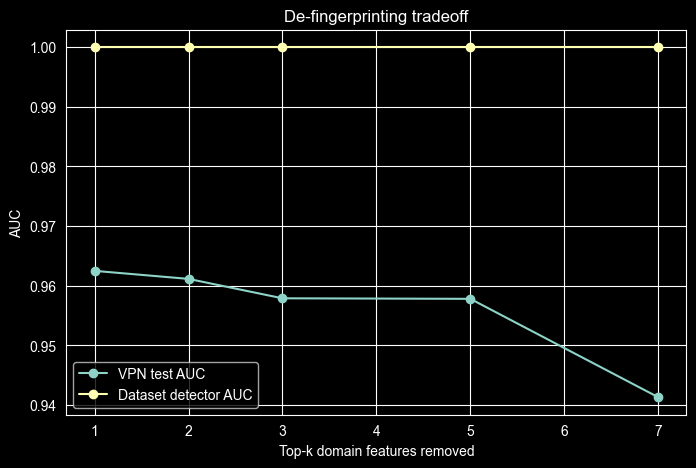

In [7]:
print("="*80)
print("DOMAIN DETECTOR + DE-FINGERPRINTING")
print("="*80)

FULL_FEATURES = pipe.model_feature_names()
CORE_FEATURES = [f for f in FULL_FEATURES if not f.startswith("h_")]
BLIND_FEATURES = [
    "sz_mean_max",
    "sz_mean_min",
    "sz_std_max",
    "sz_std_min",
    "sz_all_median",
]

def detector_auc(feature_cols):
    X_train = pipe.transform(df_train)[feature_cols]
    y_train_ds = (df_train["dataset"] == "usbvpn").astype(int).values

    X_test = pipe.transform(df_test)[feature_cols]
    y_test_ds = (df_test["dataset"] == "usbvpn").astype(int).values

    det = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric="auc",
        random_state=SEED,
        n_jobs=4
    )
    det.fit(X_train, y_train_ds)
    p_test = det.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test_ds, p_test)

    imp = pd.DataFrame({
        "feature": feature_cols,
        "importance": det.feature_importances_
    }).sort_values("importance", ascending=False)

    return auc, det, imp

for name, feats in [("full", FULL_FEATURES), ("core", CORE_FEATURES), ("blind", BLIND_FEATURES)]:
    auc, _, imp = detector_auc(feats)
    print(f"{name} detector AUC: {auc:.4f}")
    print(imp.head(10).to_string(index=False))
    print("-"*40)

core_auc, core_det, core_imp = detector_auc(CORE_FEATURES)

k_values = [1, 2, 3, 5, 7]
rows = []

for k in k_values:
    topk = core_imp["feature"].head(k).tolist()
    reduced = [f for f in CORE_FEATURES if f not in topk]

    model = fit_xgb(df_train, reduced)
    y_test_vpn, p_test_vpn = predict_df(model, df_test, reduced)
    vpn_auc = roc_auc_score(y_test_vpn, p_test_vpn)

    red_auc, _, _ = detector_auc(reduced)

    rows.append({
        "k_removed": k,
        "removed_features": ", ".join(topk),
        "n_remaining": len(reduced),
        "vpn_test_auc": vpn_auc,
        "dataset_detector_auc": red_auc,
    })

de_fingerprint_df = pd.DataFrame(rows)
print(de_fingerprint_df.to_string(index=False, float_format="%.4f"))

plt.figure(figsize=(8, 5))
plt.plot(de_fingerprint_df["k_removed"], de_fingerprint_df["vpn_test_auc"], marker="o", label="VPN test AUC")
plt.plot(de_fingerprint_df["k_removed"], de_fingerprint_df["dataset_detector_auc"], marker="o", label="Dataset detector AUC")
plt.xlabel("Top-k domain features removed")
plt.ylabel("AUC")
plt.title("De-fingerprinting tradeoff")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
print("="*80)
print("PERMUTATION IMPORTANCE BY DATASET")
print("="*80)

final_model = fit_xgb(df_train, COMPACT_FEATURES)

rows = []
rng = np.random.default_rng(SEED)

for ds in sorted(df_test["dataset"].unique()):
    sub = df_test[df_test["dataset"] == ds].copy()
    y_true, p_base = predict_df(final_model, sub, COMPACT_FEATURES)
    base_auc = roc_auc_score(y_true, p_base)

    X_sub = pipe.transform(sub)[COMPACT_FEATURES].copy()

    for feat in COMPACT_FEATURES:
        X_perm = X_sub.copy()
        X_perm[feat] = rng.permutation(X_perm[feat].values)
        p_perm = final_model.predict_proba(X_perm)[:, 1]
        auc_perm = roc_auc_score(y_true, p_perm)

        rows.append({
            "dataset": ds,
            "feature": feat,
            "base_auc": base_auc,
            "perm_auc": auc_perm,
            "auc_drop": base_auc - auc_perm,
        })

perm_df = pd.DataFrame(rows)
print(perm_df.sort_values(["dataset", "auc_drop"], ascending=[True, False]).to_string(index=False, float_format="%.4f"))

PERMUTATION IMPORTANCE BY DATASET
dataset       feature  base_auc  perm_auc  auc_drop
   iscx   sz_mean_max    0.7320    0.6079    0.1241
   iscx    sz_std_min    0.7320    0.6605    0.0715
   iscx    sz_std_max    0.7320    0.6748    0.0571
   iscx   sz_mean_min    0.7320    0.6804    0.0515
   iscx   sz_all_mean    0.7320    0.7320    0.0000
   iscx    sz_all_std    0.7320    0.7320    0.0000
   iscx    sz_all_p25    0.7320    0.7320    0.0000
   iscx sz_all_median    0.7320    0.7320    0.0000
   iscx    sz_all_p75    0.7320    0.7320    0.0000
 usbvpn sz_all_median    0.9777    0.8621    0.1155
 usbvpn    sz_std_max    0.9777    0.9533    0.0244
 usbvpn   sz_mean_min    0.9777    0.9560    0.0217
 usbvpn    sz_all_p75    0.9777    0.9576    0.0200
 usbvpn    sz_all_p25    0.9777    0.9618    0.0158
 usbvpn   sz_all_mean    0.9777    0.9655    0.0122
 usbvpn    sz_std_min    0.9777    0.9686    0.0091
 usbvpn    sz_all_std    0.9777    0.9700    0.0077
 usbvpn   sz_mean_max    0.977

In [9]:
print("="*80)
print("NEAREST-NEIGHBOR OVERLAP TEST")
print("="*80)

X_train = pipe.transform(df_train)[COMPACT_FEATURES].copy()
X_test = pipe.transform(df_test)[COMPACT_FEATURES].copy()

nn = NearestNeighbors(n_neighbors=5, metric="euclidean")
nn.fit(X_train)

distances, indices = nn.kneighbors(X_test)

train_dataset_arr = df_train["dataset"].values
test_dataset_arr = df_test["dataset"].values

rows = []
for i in range(len(df_test)):
    neigh_ds = train_dataset_arr[indices[i]]
    same_dataset_prop = np.mean(neigh_ds == test_dataset_arr[i])
    rows.append({
        "test_dataset": test_dataset_arr[i],
        "same_dataset_neighbor_prop": same_dataset_prop,
    })

nn_df = pd.DataFrame(rows)
print(nn_df.groupby("test_dataset")["same_dataset_neighbor_prop"].agg(["mean", "std", "count"]))

NEAREST-NEIGHBOR OVERLAP TEST
                  mean       std  count
test_dataset                           
iscx          0.916034  0.205378   1634
usbvpn        0.999363  0.021599   7540
vnat          0.820000  0.318159    210


In [10]:
print("=" * 80)
print("INTERACTIVE PCA VISUALIZATION (PLOTLY 3D)")
print("=" * 80)

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

# -----------------------------
# 1. Prepare transformed feature matrix
# -----------------------------
X_all = pipe.transform(df_all)[COMPACT_FEATURES].copy()

pca_3d = PCA(n_components=3, random_state=SEED)
Z_3d = pca_3d.fit_transform(X_all)

viz_df = df_all[["dataset", "label", "split"]].copy().reset_index(drop=True)
viz_df["pc1"] = Z_3d[:, 0]
viz_df["pc2"] = Z_3d[:, 1]
viz_df["pc3"] = Z_3d[:, 2]

sample_df = viz_df.sample(min(10000, len(viz_df)), random_state=SEED).copy()

print("Explained variance ratio:")
print({
    "PC1": round(float(pca_3d.explained_variance_ratio_[0]), 4),
    "PC2": round(float(pca_3d.explained_variance_ratio_[1]), 4),
    "PC3": round(float(pca_3d.explained_variance_ratio_[2]), 4),
    "Total": round(float(pca_3d.explained_variance_ratio_[:3].sum()), 4),
})

# -----------------------------
# 2. Interactive 2D PCA plots
# -----------------------------
fig_2d_dataset = px.scatter(
    sample_df,
    x="pc1",
    y="pc2",
    color="dataset",
    hover_data=["label", "split"],
    title="2D PCA projection colored by dataset",
    opacity=0.6,
)
fig_2d_dataset.update_traces(marker=dict(size=5))
fig_2d_dataset.show()

fig_2d_label = px.scatter(
    sample_df,
    x="pc1",
    y="pc2",
    color=sample_df["label"].astype(str),
    hover_data=["dataset", "split"],
    title="2D PCA projection colored by VPN label",
    opacity=0.6,
)
fig_2d_label.update_traces(marker=dict(size=5))
fig_2d_label.show()

# -----------------------------
# 3. Interactive 3D PCA plot colored by dataset
# -----------------------------
fig_3d_dataset = px.scatter_3d(
    sample_df,
    x="pc1",
    y="pc2",
    z="pc3",
    color="dataset",
    hover_data=["label", "split"],
    title="Interactive 3D PCA projection colored by dataset",
    opacity=0.6,
)
fig_3d_dataset.update_traces(marker=dict(size=3))
fig_3d_dataset.update_layout(scene=dict(
    xaxis_title="PC1",
    yaxis_title="PC2",
    zaxis_title="PC3"
))
fig_3d_dataset.show()

# -----------------------------
# 4. Interactive 3D PCA plot colored by label
# -----------------------------
fig_3d_label = px.scatter_3d(
    sample_df,
    x="pc1",
    y="pc2",
    z="pc3",
    color=sample_df["label"].astype(str),
    hover_data=["dataset", "split"],
    title="Interactive 3D PCA projection colored by VPN label",
    opacity=0.6,
)
fig_3d_label.update_traces(marker=dict(size=3))
fig_3d_label.update_layout(scene=dict(
    xaxis_title="PC1",
    yaxis_title="PC2",
    zaxis_title="PC3"
))
fig_3d_label.show()

# -----------------------------
# 5. Interactive 3D PCA biplot
# -----------------------------
# Use a smaller sample for the biplot so it stays responsive
biplot_sample_df = viz_df.sample(min(3000, len(viz_df)), random_state=SEED).copy()
biplot_indices = biplot_sample_df.index.to_numpy()
scores = Z_3d[biplot_indices, :3]

# Loadings: one vector per feature
loadings = pca_3d.components_.T[:, :3]

# Scale arrows so they are visible in PCA space
score_scale = np.max(np.abs(scores))
loading_scale = np.max(np.abs(loadings))
arrow_scale = 0.35 * score_scale / loading_scale if loading_scale > 0 else 1.0
scaled_loadings = loadings * arrow_scale

fig_biplot = go.Figure()

# Scatter points
for lbl in sorted(biplot_sample_df["label"].unique()):
    sub = biplot_sample_df[biplot_sample_df["label"] == lbl]
    idx = sub.index.to_numpy()
    fig_biplot.add_trace(
        go.Scatter3d(
            x=Z_3d[idx, 0],
            y=Z_3d[idx, 1],
            z=Z_3d[idx, 2],
            mode="markers",
            name=f"Label {lbl}",
            marker=dict(size=3, opacity=0.45),
            text=[
                f"dataset={d}<br>label={l}<br>split={s}"
                for d, l, s in zip(sub["dataset"], sub["label"], sub["split"])
            ],
            hoverinfo="text",
        )
    )

# Feature loading lines + labels
for i, feat in enumerate(COMPACT_FEATURES):
    x_end, y_end, z_end = scaled_loadings[i, 0], scaled_loadings[i, 1], scaled_loadings[i, 2]

    fig_biplot.add_trace(
        go.Scatter3d(
            x=[0, x_end],
            y=[0, y_end],
            z=[0, z_end],
            mode="lines",
            line=dict(width=6),
            name=f"loading: {feat}",
            showlegend=False,
            hoverinfo="skip",
        )
    )

    fig_biplot.add_trace(
        go.Scatter3d(
            x=[x_end],
            y=[y_end],
            z=[z_end],
            mode="text",
            text=[feat],
            textposition="top center",
            showlegend=False,
            hoverinfo="text",
        )
    )

fig_biplot.update_layout(
    title="Interactive 3D PCA Biplot",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    height=800,
)
fig_biplot.show()


INTERACTIVE PCA VISUALIZATION (PLOTLY 3D)
Explained variance ratio:
{'PC1': 0.5333, 'PC2': 0.1809, 'PC3': 0.1665, 'Total': 0.8807}
